In [2]:
#to-do list

#test hit finding where the peak doesn't ionise

In [250]:
import sys
sys.path.insert(1, 'OneDrive/Documents/GitHub/PyParse')
import pandas as pd
import math
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from statistics import mean
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import matplotlib.cm as cm
import numpy as np
import time

import getWatersData
#import cpAssignment
import plotting
import genOutput
import plate_tools

In [4]:
#inputfile = "example_dataset/Waters/Example1/example_rpt.rpt"
inputfile = "example_dataset/Waters/Example2/LC-MS Data for 48-Well Plate.rpt"
test = getWatersData.rawWatersData(inputfile)

In [5]:
test.getWellFormat()

In [6]:
test.processDAD()
test.processMS()
test.processUV()
test.processTrace()
test.processELSD()

In [7]:

#filter to just the detector type that we want to use for this analysis
test.rawTraceTable = test.rawTraceTable.loc[test.rawTraceTable["detector_type"] == "DAD"]

In [231]:

class Assignment:
    def __init__(self, filename, plate_col_no, plate_row_no):   
        #read csv file into dataframe
        #replace empty cells with an empty string
        #convert all column names to lower case and remove whitespace
        self.inputCSV = pd.read_csv(filename)
        self.inputCSV.fillna("", inplace=True)
        self.inputCSV.columns = self.inputCSV.columns.str.strip().str.lower()
        
        self.plate_col_no = plate_col_no
        self.plate_row_no = plate_row_no
        
        
    
    #Fn to convert a well name like B5 to machine format (11)
    def convertWellToNum(self, wells):
        result = []
        
        for well in wells:
            row = well[0]
            column = well[1:]
            #if the format of the row/column conforms to expectations
            if isinstance(int(column[0]), int):
                result.append(int((ord(row) - 65) * self.plate_col_no + int(column)))
            #Plates with more than 26 rows are unsupported at present. 
            else:
                logging.info("The well specified implies an unsupported plate.")
                sys.exit(2)
        return result
    
    #Fn to convert smiles into canonicalised smiles
    def getCanonSmiles(self, smiles):
        mol = Chem.MolFromSmiles(smiles.strip())
        return Chem.MolToSmiles(mol)
            
    def generateCPTable(self):
        compound_list = []
        type_dic = {
            "desired product smiles": "Product",
            "limiting reactant smiles":"Reactant",
            "internalstd smiles": "InternalSTD"
        }
        counter = {
            "desired product smiles": 1,
            "limiting reactant smiles": 1,
            "byproduct": 1
        }
        
        #Canonicalise all the incoming smiles in key columns in case the user hadn't done so already
        for col in self.inputCSV:
            if col in type_dic or ("byproduct" in col and "smiles" in col):
                self.inputCSV[col] = self.inputCSV[col].apply(self.getCanonSmiles)
        
        for col in self.inputCSV:
            if col in type_dic or ("byproduct" in col and "smiles" in col):
                cpname_column = f'{col.split(" smiles")[0]} name'
                cprt_column = f'{col.split(" smiles")[0]} rt'
                
                #group the input CSV by canonical smiles in that column, aggregated the wells into a list
                groupeddf = self.inputCSV.groupby(col, as_index=False)[["well"]].agg(lambda x: list(x))
                
                #Iterate through each of those grouped entries
                for index, row in groupeddf.iterrows():
                    cpindex = row[col]
                    cptype = type_dic[col] if col in type_dic else "Byproduct"
                    #get a name for the compound if one was provided
                    name = ""
                    if cpname_column in self.inputCSV.columns:
                        name_series = self.inputCSV.loc[self.inputCSV[col] == row[col]][cpname_column]
                        potential_names = [x for x in name_series if x != ""]
                        if len(potential_names) != 0:
                            name = potential_names[0]
                    #if a name could not be generated, create a generic one using a simple counter
                    if name == "":
                        if col == "internalstd smiles":
                            name = "InternalSTD"
                        elif col in counter:
                            name = f'{type_dic[col]}{counter[col]}'
                            counter[col] = counter[col] + 1
                        elif "byproduct" in col:
                            name = f'Byproduct{counter["byproduct"]}'
                            counter["byproduct"] = counter["byproduct"] + 1
                    
                    #get a rentention time for the compound if one was provided
                    rt = 0
                    if cprt_column in self.inputCSV.columns:
                        rt_series = self.inputCSV.loc[self.inputCSV[col] == row[col]][cprt_column]
                        potential_rt = [x for x in rt_series if x != ""]
                        if len(potential_rt) != 0:
                            rt = potential_rt[0]
                            
                    new_entry = {
                        "smiles": cpindex,
                        "type": cptype,
                        "locations": row["well"],
                        "name": name,
                        "rt": rt,
                        "comments": []
                    }
                    compound_list.append(new_entry)
        
        self.cpTable = pd.DataFrame(compound_list)
        
        #set the index to be the canonicalised smiles
        self.cpTable.index = list(self.cpTable["smiles"])
        
        #convert the "A1" style well IDs into a integer, to allow matching to a well in the rawData
        self.cpTable["locations"] = self.cpTable["locations"].apply(self.convertWellToNum)
    

    
    def generateEMs(self, calc_boc):
        
        def getMW(smiles):
            mol = Chem.MolFromSmiles(smiles)
            return round(Descriptors.ExactMolWt(mol), 2)
        
        def transform_and_getMW(smiles, smirks, stage):
            try:
                mol = Chem.MolFromSmiles(smiles)
                rxn1 = AllChem.ReactionFromSmarts(smirks)
                new_mol1 = rxn1.RunReactants((mol, ))[0][0]
                #Sanitise the molecule to make sure that a sensible molecule was produced. 
                Chem.SanitizeMol(new_mol1)
                return round(Descriptors.ExactMolWt(new_mol1), 2)
            except:
                if ("Cl" in smiles or "Br" in smiles) and stage == "mass2":
                    mol = Chem.MolFromSmiles(smiles)
                    return round(Descriptors.ExactMolWt(mol), 2) + 2
                else:
                    return 0
            
        self.cpTable["mass1"] = self.cpTable["smiles"].apply(lambda smiles: getMW(smiles))
        
        if calc_boc == "True":
            
            smirks1 = "[NX3,n:1][C:2](=[O:3])[O:4][C]([CH3])([CH3])[CH3]>>[*:1][C:2](=[O:3])[O:4]"
            self.cpTable["mass2"] = self.cpTable["smiles"].apply(lambda smiles: transform_and_getMW(smiles, smirks1, "mass2"))
            
            smirks2 = "[NX3,n:1][C](=[O])[O][C]([CH3])([CH3])[CH3]>>[*:1][H]"
            self.cpTable["mass3"] = self.cpTable["smiles"].apply(lambda smiles: transform_and_getMW(smiles, smirks2, "mass3"))
            

    def findHits(self, msData, lcData, mass_abs_tol = 0.5, min_massconf_threshold = 10, 
                                      time_abs_tol = 0.025, calc_higherions = "True"):
        
        def getMatches(compound):
            
            def getMassWithHighestConf(row):

                MS_plus = list(df.loc[(df.index.isin(MS_hits)) & (df["MStype"] == "+") &
                                       (df["MSintensity"] == row["max_intensity"]), "MSvalue"])
                MS_minus = list(df.loc[(df.index.isin(MS_hits)) & (df["MStype"] == "-") &
                                       (df["MSintensity"] == row["max_intensity"]), "MSvalue"])
                row["MS_plus"] = MS_plus[0] if len(MS_plus) > 0 else "-"
                row["MS_minus"] = MS_minus[0] if len(MS_minus) > 0 else "-"
                
                return row
            
            df = msData.loc[msData["well"].isin(compound["locations"])]
            
            MS_hits = []
            
            for mass in [compound["mass1"], compound["mass2"], compound["mass3"]]:
                hits = df.loc[(df["MStype"] == "+") & 
                                   ((abs(df["MSvalue"] - (mass + 1.01)) <= mass_abs_tol) |
                                    (abs(df["MSvalue"] - (mass + 2.02)/2) <= mass_abs_tol) |
                                    (abs(df["MSvalue"] - (mass + 3.03)/3) <= mass_abs_tol))]
                MS_hits = MS_hits + list(hits.index.values)
                
                hits = df.loc[(df["MStype"] == "-") & 
                                   (abs(df["MSvalue"] - (mass - 1.01)) <= mass_abs_tol)]
                MS_hits = MS_hits + list(hits.index.values)
            
            grouped = (df[df.index.isin(MS_hits)].groupby(["well", "peakID"], as_index = False)
                        .agg(mass_conf = ("perc_intensity", "sum"), max_intensity = ("MSintensity", "max")))
            grouped = grouped.apply(getMassWithHighestConf, axis = 1)
           
            grouped = grouped.loc[grouped["mass_conf"] >= min_massconf_threshold]
            grouped = grouped.drop("max_intensity", axis=1)
            
            #fetch any peaks where the time matches the retention time provided
            
            new_slice = lcData.loc[lcData["well"].isin(compound["locations"]) & 
                                  (abs(lcData["time"] - compound["rt"]) < time_abs_tol), ["well", "peakID"]]
            #For these additional hits, set the requisite columns so that the two sets of hits can be merged into a 
            #single dataframe. 
            new_slice["mass_conf"] = 0
            new_slice["MS_plus"] = "-"
            new_slice["MS_minus"] = "-"

            return pd.concat([grouped, new_slice], axis=0).to_dict("records")                      

        self.cpTable["hits"] = self.cpTable.apply(getMatches, axis = 1)
    
    def clusterHits(self, hits, lcData, time_abs_tol = 0.025):
        
        df = lcData.loc[lcData.index.isin(hits)]
        df.sort_values("time", inplace = True)

        clusters = []
        for index in df.index:
            if len(clusters) == 0:
                clusters.append([index])
            else:
                clusterFound = False
                for cluster in clusters:
                    mean_rt = mean([df.loc[i, "time"] for i in cluster])

                    if abs(mean_rt - df.loc[index, "time"]) < time_abs_tol:
                        cluster.append(index)
                        clusterFound = True
                        break
                if not clusterFound:
                    clusters.append([index])

        clusterbands = []
        for cluster in clusters:
            mean_time = lcData.loc[lcData.index.isin(cluster)]["time"].mean()
            clusterbands.append([round(mean_time, 5), cluster])
            
        return [clusters, clusterbands]
        
    def validateHits(self, lcData, msData, uvData, time_abs_tol = 0.025, massconf_threshold = 0.5, uv_abs_tol = 10,
                    uv_cluster_threshold = 0.5, uv_match_threshold = 0.5, cluster_size_threshold = 0.8, min_no_of_wells = 5,
                    validate = "True", mass_or_area = "mass_conf"):
              
        def clusterRow(row):
                
            relevant_indexes = []
            for hit in row["hits"]:
                relevant_indexes = (relevant_indexes + list(lcData[(lcData["well"] == hit["well"]) & 
                                                                (lcData["peakID"] == hit["peakID"])].index.values)) 
            
            outcome = self.clusterHits(relevant_indexes, lcData, time_abs_tol)
            row["clusters"] = outcome[0]
            row["cluster_bands"] = outcome[1]

            return row
                       
        def selectCluster_ifrt(row):
            comments = row["comments"]
            #If the user has specified a retention time, we should select only the cluster 
            #that is closest to that retention time, and within the specified time_abs_tol
            if row["rt"] != 0:
                suitable_clusters = [index for index, i in enumerate(row["cluster_bands"]) if abs(i - row["rt"]) < time_abs_tol]

                #If there is more than one cluster close to the specified retention time
                #take only the cluster which is closest 
                if len(suitable_clusters) > 1:
                    diffs = [row["cluster_bands"][index]-row["rt"] for index in suitable_clusters]
                    index_min = min(range(len(diffs)), key=diffs.__getitem__)
                    row["clusters"] = [row["clusters"][suitable_clusters[index_min]]]
                    #Update the cluster bands to only include the correct label
                    cluster_bands = [row["cluster_bands"][suitable_clusters[index_min]]]

                    row["comments"].append("<strong>Multiple clusters were found close the specified"
                                        " retention time.</strong>")
                    row["comments"].append(f'<strong>Cluster {index_min} was selected as it was closest'
                                        ' to the specified retention time.</strong>')
                elif len(suitable_clusters) == 1:
                    row["clusters"] = [row["clusters"][suitable_clusters[0]]]
                    row["cluster_bands"] = [row["cluster_bands"][suitable_clusters[0]]]
                    row["comments"].append("<strong>A single cluster was found close the specified"
                                        " retention time and this was selected for analysis.</strong>")
                else:
                    row["comments"].append("<strong>No cluster was found near to the specified "
                                        "retention time. Proceeding with analysis using all "
                                        f'{len(row["clusters"])} clusters.</strong>')
            return row
            
        def refineClustersByTime(row):
            """
            Takes in input cluster of all the hit peaks, 
            and refines them by finding a mid-value for the retention
            time based on which hit has the greatest number of nearest neighbours. 
            Sorts the best hits into "green", uncertain ones into "orange" 
            and those where another peak closer to the mid-value was found
            in the same well into "discarded". 

            :param cluster: list of dictionaries, where each dictionary is a hit
            :param comments: A list of comments for that structure so far.

            :return: List comprising [a dictionary for the refined cluster, list of comments]
            """

            [clusters, comments, expected_rt] = [row["clusters"], row["comments"], row["rt"]]
            refined_clusters = []

            for cluster in clusters:
                refined_cluster = {
                    "green":[],
                    "orange": [],
                    "discarded": [],
                }

                mid_values = []
                mid_value = 0

                if expected_rt != 0:
                    mid_value = expected_rt
                else: 
                    for i in cluster:
                        mid_value = lcData.loc[i, "time"]
                        mid_values.append([mid_value, len([lcData.loc[j, "time"] for j in cluster 
                                                           if abs(lcData.loc[j, "time"] - mid_value) < time_abs_tol/4])])
                    mid_value = max(mid_values, key = lambda x: x[1])[0]

                #sort the peaks by the well they occupy
                peaks_by_wells = {}
                for i in cluster:
                    if lcData.loc[i, "well"] not in peaks_by_wells:
                        peaks_by_wells[lcData.loc[i, "well"]] = []
                    peaks_by_wells[lcData.loc[i, "well"]].append(i)

                #For each well, select the peak that's closest to the mid-value in cases
                #where there was more than one hit in that cluster in one well
                #Use peakAdded to ensure that only a single peak per well is added to green, in the 
                #unlikely case that there are two peaks in the same well with the same retention time
                #(i.e. LCMS machine processing error)
                for index, well in peaks_by_wells.items():
                    if len(well) > 1:
                        min_diff = min([abs(lcData.loc[i, "time"]-mid_value) for i in well])
                        peakAdded = False
                        for i in well:

                            if abs(lcData.loc[i, "time"]-mid_value) == min_diff and not peakAdded:
                                refined_cluster["green"].append(i)
                                peakAdded = True
                            else:
                                refined_cluster["discarded"].append(i)
                                row["comments"].append(f'Peak at {lcData.loc[i, "time"]} '
                                            f'in well {plate_tools.getUserReadableWell(index, self.plate_col_no)} was discarded '
                                            'as there was an alternative peak '
                                            'in the same well which was closer to the '
                                            'mid-point of the cluster.')
                    else:
                        refined_cluster["green"].append(well[0])

                #Refine these hits further by finding those which are within time_abs_tol/2
                #of the mid-value. Any others are marked as tentative and the user is alerted.         
                ref2_cluster = {
                    "green":[],
                    "orange": refined_cluster["orange"],
                    "discarded": refined_cluster["discarded"],
                }        
                
                for i in refined_cluster["green"]:
                    if abs(lcData.loc[i, "time"] - mid_value) < time_abs_tol / 2:
                        ref2_cluster["green"].append(i)
                    else:
                        ref2_cluster["orange"].append(i)
                        comments.append(f'Peak at {lcData.loc[i, "time"]} in '
                                       f'well {plate_tools.getUserReadableWell(lcData.loc[i, "well"], self.plate_col_no)} was '
                                       'marked as tentative as it was found to be too '
                                       'far from the mid-value of the cluster.')
                refined_clusters.append(ref2_cluster)

            row["clusters"] = refined_clusters
            return row
        
        def refineClustersByMassConf(row):
            """
            Takes in input cluster of all the hit peaks, 
            and refines them by ensuring all peaks have a similar mass confidence
            to the cluster's mean. Those which do are left in "green"; 
            those which don't are moved to the "orange" category.

            :param cluster: a dict, with list of dicts for each header
            :param comments: A list of comments for the compound so far

            :return: List comprising [a dictionary for the refined cluster, list of comments]
            """
            refined_clusters = []
            for cluster in row["clusters"]:
                refined_cluster = {
                    "green": [],
                    "orange": cluster["orange"],
                    "discarded": cluster["discarded"],
                }
                if len(cluster["green"]) > 0:
                    #Get a dictionary of the mass_conf for each peak, indexed by the index present in lcData
                    mass_conf_dict = {}
                    for i in cluster["green"]:
                        well = lcData.loc[i, "well"]
                        peakID = lcData.loc[i, "peakID"]
                        for j in row["hits"]:
                            if j["well"] == well and j["peakID"] == peakID:
                                mass_conf_dict[i] = j["mass_conf"]

                    #find what the mean mass confidence is of all peaks
                    #currently under the "green" category
                    total = sum(mass_conf_dict[x] for x in cluster["green"])
                    mean_mass_conf = total / len(cluster["green"])

                    for i in cluster["green"]:
                        if mass_conf_dict[i] < mean_mass_conf * massconf_threshold:
                            refined_cluster["orange"].append(i)
                            row["comments"].append(f'Peak at {lcData.loc[i, "time"]} in well '
                                            f'{plate_tools.getUserReadableWell(lcData.loc[i, "well"], self.plate_col_no)} '
                                            'was marked tentative due to poor mass '
                                            'confidence in comparison to the rest of the cluster.')
                        else:
                            refined_cluster["green"].append(i)
                refined_clusters.append(refined_cluster)
            row["clusters"] = refined_clusters
            return row
        
        def refineClustersByUV(row):
            """
            Takes in input cluster of all the hit peaks, 
            and refines the cluster by ensuring all peaks have a similar set
            of UV maxima. Those which do are left in "green", those which
            don't are moved to the "orange" category

            :param cluster: a dict, with list of dicts for each header
            :param UVdatafound: boolean for whether the rpt data contains UV data
            :param comments: A list of comments for that structure so far

            :return: List comprising [a dictionary for the refined cluster, list of comments]
            """
            refined_clusters = []
            
            for cluster in row["clusters"]:
                refined_cluster = {
                    "green": [],
                    "orange": cluster["orange"],
                    "discarded": cluster["discarded"],
                }

                if len(cluster["green"]) > 0:
                    

                    UVclusters = []

                    for i in cluster["green"]:
                        for UV in uvData.loc[(uvData["well"] == lcData.loc[i, "well"]) & (uvData["peakID"] == lcData.loc[i, "peakID"])]["UVvalue"]:
                            if len(UVclusters) == 0:
                                UVclusters.append([UV])

                            else:
                                clusterFound = False
                                for UVcluster in UVclusters:
                                    if abs(UVcluster[-1] - UV) < uv_abs_tol:
                                        UVcluster.append(UV)
                                        clusterFound = True
                                        break
                                if not clusterFound:
                                    UVclusters.append([UV])

                    meanUV = []
                    #Check to ensure UVclusters isn't an empty set
                    if len(UVclusters) > 0:
                        lengthOfMostCommon = max([len(UVcluster) for UVcluster in UVclusters])

                        for UVcluster in UVclusters:
                            if len(UVcluster) >= lengthOfMostCommon * uv_cluster_threshold:
                                meanUV.append(mean(UVcluster))

                        for i in cluster["green"]:
                            UVvalues = (uvData.loc[(uvData["well"] == lcData.loc[i, "well"]) 
                                               & (uvData["peakID"] == lcData.loc[i, "peakID"])]["UVvalue"].values)
                            intersection = []
                            for meanvalue in meanUV:
                                for UV in UVvalues:
                                    if abs(meanvalue - UV) < uv_abs_tol:
                                        intersection.append(meanvalue)

                            if len(intersection) >= len(meanUV) * uv_match_threshold:
                                refined_cluster["green"].append(i)
                            else:
                                refined_cluster["orange"].append(i)
                                row["comments"].append(f'Peak at {lcData.loc[i, "time"]} in well '
                                                f'{plate_tools.getUserReadableWell(lcData.loc[i, "time"], self.plate_col_no)} '
                                                'was marked tentative due to mismatch in UV maxima with the rest of the cluster.')
                    #If UVclusters is an empty set, pass through the original hits without further
                    #validation. 
                    else:
                        row["comments"].append('UV validation not permitted where cluster contains peaks with no UV data. '
                            'UV validation was not performed.')
                        refined_cluster["green"] = cluster["green"]
                else:
                    row["comments"].append('UV data was not found for the plate, so UV validation was not performed.')
                    refined_cluster["green"] = cluster["green"]
                refined_clusters.append(refined_cluster)
            
            row["clusters"] = refined_clusters
            return row
        
        def selectClusterByMassConf(row):
            """
            If more than one cluster was found for the compound, 
            this function is called to try to select a single cluster based on 
            which cluster has the highest mean massConf. If more than one cluster
            has a close-to-highest-mean massconf, take them all. 

            :param clusters: a list of dictionaries, with list of dictionaries for each header
            :return refined_clusters: a list of dictionaries, with list of dictionaries for each header

            :return discarded_clusters: a list of dictionaries, with list of dictionaries for each header
            """
            
            refined_clusters = []
            discarded_clusters = []

            means = []
            #find the mean massconf for each cluster
            for cluster in row["clusters"]:
                if len(cluster["green"]) > 0:
                    #Get a dictionary of the mass_conf for each peak, indexed by the index present in lcData
                    mass_conf_dict = {}
                    for i in cluster["green"]:
                        well = lcData.loc[i, "well"]
                        peakID = lcData.loc[i, "peakID"]
                        for j in row["hits"]:
                            if j["well"] == well and j["peakID"] == peakID:
                                mass_conf_dict[i] = j["mass_conf"]
                    
                    #Calculate the mean mass_conf of the cluster
                    mean_mass_conf = sum([mass_conf_dict[i] for i in cluster["green"]]) / len(cluster["green"])
                    means.append(mean_mass_conf)
                else:
                    means.append(0)
                    
            #find the maximum mean value to compare all clusters against
            max_mean = max(means)
            
            #Filter the clusters by those which have a mean mass confidence that is at least the specified
            #percentage of the maximum observed mean mass confidence (set by massconf_threshold, typically 80%)
            for i in range(len(means)):
                if max_mean * massconf_threshold < means[i] or (max_mean == 0 and means[i] == 0):
                    refined_clusters.append(row["clusters"][i])
                else:
                    discarded_clusters.append(row["clusters"][i])
                    
            row["refined_clusters"] = refined_clusters
            row["discarded_clusters"] = discarded_clusters
            return row

        def selectClusterBySize(row):
            """
            If more than one cluster was found for the compound, 
            this function is called to try to select a single cluster based on 
            which cluster is the largest. If more than one cluster
            has a close-to-largest size, take them all. 

            :param clusters: a list of dictionaries, with list of dictionaries for each header
            :return refined_clusters: a list of dictionaries, with list of dictionaries for each header

            :return discarded_clusters: a list of dictionaries, with list of dictionaries for each header
            """

            refined_clusters2 = []
            discarded_clusters = row["discarded_clusters"]

            lengths = [len(cluster["green"]) + len(cluster["orange"]) for cluster in row["refined_clusters"]]
            max_length = max(lengths)

            for cluster in row["refined_clusters"]:
                if len(cluster["green"]) + len(cluster["orange"]) > max_length * cluster_size_threshold:
                    refined_clusters2.append(cluster)
                else:
                    discarded_clusters.append(cluster)

            #If there is still more than one cluster, reset the process using only those peaks
            #that haven't been marked as suspicious (orange)
            if len(refined_clusters2) > 1:

                lengths = [len(cluster["green"]) for cluster in row["refined_clusters"]]
                max_length = max(lengths)

                #As long as at least one cluster had a green hit, filter the clusters by size
                if max_length != 0:
                    refined_clusters2 = []
                    discarded_clusters = row["discarded_clusters"]

                    for cluster in row["refined_clusters"]:
                        if len(cluster["green"]) > max_length * cluster_size_threshold:
                            refined_clusters2.append(cluster)
                        else:
                            discarded_clusters.append(cluster)
            row["refined_clusters"] = refined_clusters2
            row["discarded_clusters"] = discarded_clusters
            return row
        
        def indexClusterByWells(row):
            cluster_by_well = {}
            for cluster in row["refined_clusters"]:
                for i in cluster["green"]:
                    if lcData.loc[i, "well"] not in cluster_by_well:
                        cluster_by_well[lcData.loc[i, "well"]] = {
                                "green": [],
                                "orange": [],
                                "discarded": [],
                                }

                    cluster_by_well[lcData.loc[i, "well"]]["green"].append(i)

                for i in cluster["orange"]:
                    if lcData.loc[i, "well"] not in cluster_by_well:
                        cluster_by_well[lcData.loc[i, "well"]] = {
                                "green": [],
                                "orange": [],
                                "discarded": [],
                                }

                    cluster_by_well[lcData.loc[i, "well"]]["orange"].append(i)

                for i in cluster["discarded"]:
                    if lcData.loc[i, "well"] not in cluster_by_well:
                        cluster_by_well[lcData.loc[i, "well"]] = {
                                "green": [],
                                "orange": [],
                                "discarded": [],
                                }

                    cluster_by_well[lcData.loc[i, "well"]]["discarded"].append(i)
                    
            row["clusters_indexed_by_well"] = cluster_by_well
            return row
            
        def refine_and_select(row): 
            #If there are sufficient wells to perform refine and select a cluster, do so. 
            #Otherwise, simply mark all hits as "green" fill in the necessary table structure. 
            if len(row["hits"]) > min_no_of_wells and validate == "True":
                row = refineClustersByTime(row)
                row = refineClustersByMassConf(row)
                row = refineClustersByUV(row)
                row = selectClusterByMassConf(row)
                row = selectClusterBySize(row)
            else:
                refined_clusters = []
                for cluster in row["clusters"]:
                    refined_cluster = {
                        "green": [],
                        "orange": [], 
                        "discarded": []
                    }
                    for i in cluster:
                        refined_cluster["green"].append(i)
                    refined_clusters.append(refined_cluster)
                row["refined_clusters"] = refined_clusters
                row["discarded_clusters"] = []
                
                if validate != "True":
                    row["comments"].append("Validation was not performed as requested by the user.")
                else:
                    row["comments"].append(f'Validation was not performed for {row["name"]} as '
                                        'there were insufficient hits.')
            return row
        
        def finalResult(row):
            final_result = {
                "green": [],
                "discarded": []    
            }
            
            for well in row["clusters_indexed_by_well"].values():
                #Move all discarded peaks immediately to the analogous result in "final result"
                final_result["discarded"] += well["discarded"]
                
                #Depending on how many green or orange peaks were found in this well, proceed accordingly, 
                #where green peaks are selected in preference to orange ones. 
                if len(well["green"]) > 0:
                    if len(well["green"]) == 1:
                        final_result["green"].append(well["green"][0])
                    else:
                        
                        #Get a list of peaks that are deemed suitable, either those that have the largest mass confidence
                        #or, in the case where the peaks are selected purely by their area, a dummy list. 
                        #We're going 
                        if mass_or_area == "mass_conf":
                            #Get a dictionary of the mass_conf for each peak, indexed by the index present in lcData
                            mass_conf_dict = {}
                            for i in well["green"]:
                                peak_well = lcData.loc[i, "well"]
                                peakID = lcData.loc[i, "peakID"]
                                for j in row["hits"]:
                                    if j["well"] == peak_well and j["peakID"] == peakID:
                                        mass_conf_dict[i] = j["mass_conf"]
                                        
                            max_mass_conf = max(mass_conf_dict.values())
                                                               
                            suitable_indexes = [i for i in well["green"] if mass_conf_dict[i] == max_mass_conf]
                        else:
                            suitable_indexes = well["green"]
                            
                        sorted_list = sorted(well["green"], key = lambda x: lcData.loc[x, "area"], reverse = True)

                        peakAdded = False
                        for i in sorted_list:
                            if i in suitable_indexes and peakAdded == False:
                                final_result["green"].append(i)
                                row["comments"].append(f'Peak with largest {mass_or_area} selected in '
                                                       'preference to others available for well '
                                                       f'{plate_tools.getUserReadableWell(lcData.loc[i, "well"], self.plate_col_no)}.')
                                peakAdded = True
                            else:
                                final_result["discarded"].append(i)
                                row["comments"].append(f'The peak at {lcData.loc[i, "time"]} in well '
                                                       f' {plate_tools.getUserReadableWell(lcData.loc[i, "well"], self.plate_col_no)} '
                                                       f'was discarded as it had a smaller {mass_or_area} than an '
                                                       'otherwise equally likely alternative.')
                                                            
                    #If we had a green peak to select, we can safely move all the orange peaks into the discarded pile
                    if len(well["orange"]) > 0:
                        final_result["discarded"] += well["orange"]
                        for i in well["orange"]:
                            row["comments"].append(f'The peak at {lcData.loc[i, "time"]} in well '
                                        f'{plate_tools.getUserReadableWell(lcData.loc[i, "well"], self.plate_col_no)} '
                                        f'for {row["name"]} was discarded because a better match was found.')
                
                elif len(well["orange"]) == 1:
                    final_result["green"].append(well["orange"][0])
                    row["comments"].append(f'<strong>The tentative peak at {lcData.loc[well["orange"][0], "time"]} in well '
                                        f'{plate_tools.getUserReadableWell(lcData.loc[well["orange"][0], "well"], self.plate_col_no)} was '
                                        f'used as there was no better option. User should check this well.</strong>')
                elif len(well["orange"]) > 1:
                    #Get a list of peaks that are deemed suitable, either those that have the largest mass confidence
                    #or, in the case where the peaks are selected purely by their area, a dummy list. 
                    #We're going 
                    if mass_or_area == "mass_conf":
                        #Get a dictionary of the mass_conf for each peak, indexed by the index present in lcData
                        mass_conf_dict = {}
                        for i in well["orange"]:
                            peak_well = lcData.loc[i, "well"]
                            peakID = lcData.loc[i, "peakID"]
                            for j in row["hits"]:
                                if j["well"] == peak_well and j["peakID"] == peakID:
                                    mass_conf_dict[i] = j["mass_conf"]

                        max_mass_conf = max(mass_conf_dict.values())

                        suitable_indexes = [i for i in well["orange"] if mass_conf_dict[i] == max_mass_conf]
                    else:
                        suitable_indexes = well["orange"]

                    sorted_list = sorted(well["orange"], key = lambda x: lcData.loc[x, "area"], reverse = True)

                    peakAdded = False
                    for i in sorted_list:
                        if i in suitable_indexes and peakAdded == False:
                            final_result["green"].append(i)
                            row["comments"].append(f'Tentatively assigned peak with largest {mass_or_area} selected in '
                                                   'preference to other tentative assignments available for well '
                                                   f'{plate_tools.getUserReadableWell(lcData.loc[i, "well"], self.plate_col_no)}.')
                            peakAdded = True
                        else:
                            final_result["discarded"].append(i)
                            row["comments"].append(f'<strong>The peak at {lcData.loc[i, "time"]} in well '
                                                   f' {plate_tools.getUserReadableWell(lcData.loc[i, "well"], self.plate_col_no)} '
                                                   f'was discarded as it had a smaller {mass_or_area} than an '
                                                   'otherwise equally likely alternative.</strong>')
                    
            row["final_result"] = final_result
            return row
        

                
            
        self.cpTable = self.cpTable.apply(clusterRow, axis = 1)
        self.cpTable = self.cpTable.apply(selectCluster_ifrt, axis = 1)
        
        self.cpTable = self.cpTable.apply(refine_and_select, axis = 1)
        
        self.cpTable = self.cpTable.apply(indexClusterByWells, axis = 1)
        
        self.cpTable = self.cpTable.apply(finalResult, axis = 1)
    
    
    def removeDupAssigns(self, lcData, mass_or_area):
        """
        Checks each compound to ensure that no peak has been assigned 
        to two different compounds. If this has happened, the internalSTD
        (if present) takes first priority, limiting reactant is second priority,
        product third priority and finally a by-product is lowest priority.

        :param compoundDF: Pandas dataframe
        :param internalSTD: A string representing the name of the internal standard
        :param SMs: A list of starting material names
        :param products: A list of product names
        :param by_products: A list of by_product names

        :return: compoundDF as Pandas dataframe
        """
        
        def checkForOverlap(row):
            #Get a relevant slice of the cpTable to compare this row against
            indexes = []
            if row["type"] == "Byproduct":
                indexes = self.cpTable.loc[self.cpTable["type"].isin(["Product", "InternalSTD", "Reactant"])].index.values
            elif row["type"] == "Product":
                indexes = self.cpTable.loc[self.cpTable["type"].isin(["InternalSTD", "Reactant"])].index.values
            elif row["type"] == "Reactant":
                indexes = self.cpTable.loc[self.cpTable["type"].isin(["InternalSTD"])].index.values
            
            if len(indexes) > 0:
                new_slice = self.cpTable.loc[self.cpTable.index.isin(indexes)]
                
                to_keep = []
                for i, j in enumerate(row["final_result"]["green"]):
                    overlap = False
                    for assigned_peaks in list(new_slice["final_result"]):
                        if j in assigned_peaks["green"]:
                            overlap = True
                    
                    #If overlap was found, this hit is appended to this list of discarded hits         
                    if overlap:
                        row["comments"].append(f'<strong>The peak in well {plate_tools.getUserReadableWell(lcData.loc[j, "well"], self.plate_col_no)} '
                                               f'at {lcData.loc[j, "time"]} minutes was deselected '
                                               'because it was already assigned to the SM, internalSTD or by-product.</strong>')
                        possibilities = []
                        for replacement in row["final_result"]["discarded"]:
                            #print(replacement, j)
                            if lcData.loc[j, "well"] == lcData.loc[replacement, "well"]:
                                possibilities.append(replacement)
                                
                        if len(possibilities) > 0:
                            if mass_or_area == "mass_conf":
                                mass_conf_dict = {}
                                for lcData_index in possibilities:
                                    well = lcData.loc[lcData_index, "well"]
                                    peakID = lcData.loc[lcData_index, "peakID"]
                                    for hit in row["hits"]:
                                        if hit["well"] == well and hit["peakID"] == peakID:
                                            mass_conf_dict[i] = hit["mass_conf"]

                                #Get the best replacement option based on the mass confidence of that option
                                best_option = max(mass_conf_dict, key=mass_conf_dict.get)
                            else:
                                options = lcData.loc[lcData.index.isin(possibilities)]
                                options = options.loc[options["area"] == options["area"].max()]
                                best_option = list(options["area"])[0]
                            
                            to_keep.append(best_option)
                            row["comments"].append(f'<strong>The peak in well {plate_tools.getUserReadableWell(lcData.loc[best_option, "well"], self.plate_col_no)} '
                                                   f'at {lcData.loc[best_option, "time"]} minutes was promoted to replace the '
                                                   f'peak that was deselected, and was selected for promotion as it had the largest '
                                                   f'{mass_or_area}.</strong>')
                        
                        #finally, append the now unwanted peak into the discard pile
                        row["final_result"]["discarded"].append(j)
                            
                        
                            
                    else:
                        to_keep.append(j)
                
                row["final_result"]["green"] = to_keep
            return row
        
        self.cpTable = self.cpTable.apply(checkForOverlap, axis = 1)
    
    def findPotentialConflicts(self):
        """
        Find any products which are in danger of overlapping with other compounds that
        are expected in the same well. 
        This function is useful as the program may not detect SM (etc) for that peak/well
        because the mass_conf is too low, but the user should still be warned that there 
        may be a problem. 

        :param compoundDF: Pandas datatable for compounds
        :return: A text output for that compound. 
        """
        
        def getConflicts(row):

            text = ""


            new_slice = self.cpTable.loc[((( self.cpTable["time"] - row["time"]).abs() < 0.02)
                                        & ( self.cpTable["name"] != row["name"])
                                        & ( self.cpTable["time"] != 0))]
            
            close_compounds = new_slice.apply(lambda brow: brow["name"], axis = 1)
                                              

            if len(close_compounds) > 0:
                text = "<strong>The compound was found to have a similar retention time as "
                for i, name in enumerate(close_compounds):
                    if i != len(close_compounds)-1:
                        text = f'{text}{name}, '
                    elif len(close_compounds) > 1:
                        text = f'{text}and {name}. '
                    else:
                        text = f'{text}{name}. '
                text = text + "The user should check this result manually.</strong>"
            else:
                text = "No potential conflicts found."

            row["conflicts"] = text
            return row
        self.cpTable = self.cpTable.apply(getConflicts, axis = 1)
    
    
    def setBestWell(self, outputTable, lcData, plot_type):

        def bestWellPerRow(row):


            if row["type"] == "Product":
                
                #Filter to the rows where the compound is found, then get a list of wells that have the 
                #maximum observed value for the given plot type (note: not guaranteed to return a single well!)
                new_slice = outputTable.loc[outputTable["well_no"].isin(row["locations"])]
                best_well_poss = list(new_slice.loc[(new_slice[plot_type] == new_slice[plot_type].max()) & 
                                    (new_slice[plot_type] > 0),  "well_no"])

                if len(best_well_poss) > 0:
                    best_well = best_well_poss[0]
                
                #If no "best well" is found (perhaps because the internal standard wasn't found in that well, 
                #set the best well to be the one where the highest Parea was observed. 
                else:
                    best_well_poss2 = list(new_slice.loc[(new_slice["Parea"] == new_slice["Parea"].max()) & 
                                                (new_slice["Parea"] > 0), "well_no"])
                    
                    if len(best_well_poss2) > 0:
                        best_well = best_well_poss2[0]
                    else:
                        best_well = -1

            else:
                new_slice = lcData.loc[lcData.index.isin(row["final_result"]["green"])]                 
                new_slice = new_slice.loc[new_slice["area"] == new_slice["area"].max(), "well"]
                    
                if len(list(new_slice)) > 0:
                    best_well = list(new_slice)[0]
                else:
                    best_well = -1
                
            row["best_wellno"] = best_well
            row["best_well"] = plate_tools.getUserReadableWell(best_well, self.plate_col_no) if best_well > -1 else "None found."
            return row

        self.cpTable = self.cpTable.apply(bestWellPerRow, axis = 1)
    
    def setBestMS(self, lcData):
        
        def bestMSPerRow(row):
            if row["type"] != "Impurity":
                best_well = row["best_wellno"]
                peakID = -1
                for i in row["final_result"]["green"]:
                    if lcData.loc[i, "well"] == best_well:
                        peakID = lcData.loc[i, "peakID"]

                MS_plus = "-"
                MS_minus = "-"
                if peakID > -1:
                    for hit in row["hits"]:
                        if hit["well"] == best_well and hit["peakID"] == peakID:
                            MS_plus = hit["MS_plus"]
                            MS_minus = hit["MS_minus"]
                row["mass+"] = MS_plus
                row["mass-"] = MS_minus
            return row
        
        self.cpTable = self.cpTable.apply(bestMSPerRow, axis = 1)

    def setBestTime(self, lcData):

        def bestTimePerRow(row): 
            best_well = row["best_wellno"]
            best_time = 0
            for i in row["final_result"]["green"]:
                if lcData.loc[i, "well"] == best_well:
                    best_time = lcData.loc[i, "time"]
            
            row["time"] = best_time
            return row
        
        self.cpTable = self.cpTable.apply(bestTimePerRow, axis = 1)
    
    def setBestPurity(self, lcData):
        def bestPurityPerRow(row): 
            best_well = row["best_wellno"]
            best_purity = 0
            for i in row["final_result"]["green"]:
                if lcData.loc[i, "well"] == best_well:
                    best_purity = lcData.loc[i, "area"]
            
            row["best_purity"] = best_purity
            
            return row
        
        self.cpTable = self.cpTable.apply(bestPurityPerRow, axis = 1)
        
    
    def findImpurities(self, lcData, msData, save_dir, time_abs_tol = 0.025, min_no_of_wells = 5, mass_abs_tol = 0.5):
        
        #Define function to get a list of wells from a cluster, 
        #without any duplicates
        def unique_wells(cluster):
            unique_wells = lcData.loc[lcData.index.isin(cluster), "well"].nunique()
            return unique_wells
        
        #Define sub-function to find common ions for a cluster of peaks
        def findCommonIons(valid_combos, MStype):
            
            #get all rows in msData that have the right combonations of both well and peakID
            result = (msData.loc[(msData["MStype"] == MStype) & 
                                 (msData.set_index(["well", "peakID"]).index.isin(valid_combos))])

            result.sort_values("time", inplace = True)

            #We need to find which m/z were commonly observed across this set of peaks. 
            #In this sorted data frame, find the difference between each successive row, 
            #mark any difference where the it is larger than mass_abs_tol as True,
            #then apply cumulative sum that counts the number of "Trues" seen so far
            #which is effectively a grouping index. 
            groupings = (result.groupby(result["MSvalue"].diff()
                                        .gt(mass_abs_tol)
                                        .cumsum())
                                        .apply(lambda row: list(row.index)))


            #Filter the ions down to those which appear in at least 80% of the peaks    
            filtered = [group for group in groupings if len(group) > len(cluster)*0.8]

            #Filter to just the top 5 most commonly observed peaks, to guarantee a maximum
            #number of 5 mass ions reported. 
            filtered = sorted(groupings, key = lambda x: len(x))[0:5]
            
            #get the mean value for each grouping, then return as a list
            return_ions = []
            for group in filtered:
                return_ions.append(msData.loc[msData.index.isin(group),"MSvalue"].mean())

            return return_ions
        
        #Get a list of all the peaks that have been assigned to a compound
        assigned_peaks = []
        self.cpTable.apply(lambda row: assigned_peaks.extend(row["final_result"]["green"]), axis = 1)
        
        #And therefore find a listof all the peaks that have not been assigned!
        unassigned_peaks = lcData.loc[lcData.index.isin(assigned_peaks) == False].index
        
        clusters = self.clusterHits(unassigned_peaks, lcData, time_abs_tol)[0]
        
        #filter to only those clusters where there are sufficient number of unique wells
        clusters = [i for i in clusters if unique_wells(i) > min_no_of_wells]
        
        impurities = []
        
        for index, cluster in enumerate(clusters):
            
            new_slice = lcData.loc[lcData.index.isin(cluster)]
            new_slice = new_slice.loc[new_slice["area"] == new_slice["area"].max(), ["well", "peakID", "area"]]
            best_purity = new_slice.iloc[0]["area"]
            best_well = int(new_slice.iloc[0]["well"])
            mean_rt = round(lcData.loc[lcData.index.isin(cluster), "time"].mean(), 4)
            
            valid_combos = [(lcData.loc[peak, "well"], lcData.loc[peak, "peakID"]) for peak in cluster]
            mass_plus = findCommonIons(valid_combos, "+")
            mass_minus = findCommonIons(valid_combos, "-")
            
            comments = []
        
            #Criteria to determine when a comment is added:
            #   -Cluster typically occurs in a particular column
            #   -Cluster typically occurs in a particular row
            #   -Cluster typically occurs for a particular compound in the platemap
            #   -Cluster is independant of position (i.e. whole plate) - this overrides all of the above
            #   -describe how many wells contained this impurity
            observed_unique_wells = unique_wells(cluster)
            comments.append(f'This impurity was observed in {observed_unique_wells} wells.')

            if observed_unique_wells == self.plate_row_no * self.plate_col_no:
                comments.append("This impurity was observed in every well of the plate.")
            elif observed_unique_wells > 0.5 * self.plate_row_no * self.plate_col_no:
                comments.append("This impurity was observed across the majority of the plate.")
            else:
                #Build a matrix of where the compound was observed, then iterate through each row/column in turn?
                columns = {}
                rows = {}
                for i in cluster:
                    wellno = lcData.loc[i, "well"]
                    row = math.floor((wellno-1)/self.plate_col_no) + 1
                    column = ((wellno-1) % self.plate_col_no) + 1
                    if row in rows:
                        rows[row] = rows[row] + 1
                    else:
                        rows[row] = 1
                    if column in columns:
                        columns[column] = columns[column] + 1
                    else:
                        columns[column] = 1

                for cindex, column in columns.items():
                    if column > 0.8 * self.plate_row_no:
                        comments.append(f'Impurity is frequently observed in column {cindex}.')
                for rindex, row in rows.items():
                    if row > 0.8 * self.plate_col_no:
                        comments.append(f'Impurity is frequently observed in row {chr(ord("@")+(rindex)+1)}.')
                if len(columns.keys()) < 0.5 * self.plate_col_no:
                    readable_cols = [str(i) for i in sorted([int(j) for j in columns.keys()])]
                    comments.append(f'Impurity was only observed in columns {", ".join(readable_cols)}.')
                if len(rows.keys()) < 0.5 * self.plate_row_no:
                    readable_rows = sorted([chr(ord("@")+(x)) for x in rows.keys()])
                    comments.append(f'Impurity was only observed in rows {", ".join(readable_rows)}.')
                    
            #Append this data to a new dictionary, to ultimately build into a dataframe that will be concatonated 
            #with self.cpTable
            entry = {}
            #get the columns that should be filled 
            for column in self.cpTable.columns:
                entry[column] = ""
                
            entry["name"] = f'Impurity{index}'
            entry["type"] = "Impurity"
            [entry["mass1"], entry["mass2"], entry["mass3"]] = [0,0,0]
            entry["mass-"] = mass_minus
            entry["mass+"] = mass_plus
            entry["final_result"] = {
                "green": cluster,
                "discarded": []
            }
            entry["comments"] = comments
            
            impurities.append(entry)
        
        #Turn the list of impurities into a datafram
        
        df = pd.DataFrame(impurities)
        df.index = list(df["name"])
        
        self.cpTable = pd.concat([self.cpTable, df], axis=0)
            
        #If 1 or more impurities were found, plot a hit validation graph to display these. 
        if len(clusters) > 0:
            fig, ax = plt.subplots()
            total_wells = self.plate_col_no * self.plate_row_no
            ax.set_xlim(-total_wells*0.25, total_wells*1.1)
            #Plot a hit validation graph for all clusters to more easily display the results.
            #Save this to the graphs folder. 
            palette = cm.rainbow(np.linspace(0, 1, len(clusters)))

            for index, cluster in enumerate(clusters):
                x = []
                y = []
                for i in cluster:
                    x.append(lcData.loc[i, "well"])
                    y.append(lcData.loc[i, "time"])
                plt.scatter(x, y, color = palette[index])

                #Annotate the graph with the average retention time of each cluster

                mean_rt = round(lcData.loc[lcData.index.isin(cluster), "time"].mean(), 2)

                ax.annotate(f'Imp{i}: {mean_rt} min.', [-total_wells*0.22, mean_rt], 
                            verticalalignment='center')     

            #Label the graph and axes, and save to the output directory.   
            plt.title("All Frequent Impurities Found")
            plt.xlabel("Well")
            plt.ylabel("Retention Time /min")
            plt.savefig(f'{save_dir}/graphs/impuritychart.jpg', format = "jpg")    
            plt.close()
            
        


In [214]:
cpTable = Assignment("example_dataset/Waters/Example2/PyParse_designer_platemap.csv", 12, 4)
#cpTable = Assignment("example_dataset/Waters/Example1/example_platemap.csv", 12)

In [215]:
cpTable.generateCPTable()

In [216]:
cpTable.generateEMs("True")

In [217]:
msData = test.rawMSTable
uvData = test.rawUVTable
detector = "UV"

if detector == "UV":  
    lcData = test.rawDADTable
else:
    lcData = test.rawELSDTable

In [218]:
cpTable.findHits(msData, lcData)

In [219]:
cpTable.validateHits(lcData, msData, uvData)

In [220]:
cpTable.removeDupAssigns(lcData, "mass_conf")

In [235]:
cpTable.cpTable

,smiles,type,locations,name,rt,comments,mass1,mass2,mass3,hits,...,discarded_clusters,clusters_indexed_by_well,final_result,mass-,mass+,best_wellno,best_well,time,best_purity,conflicts
OCc1coc(-c2cnc3ccccc3c2)n1,OCc1coc(-c2cnc3ccccc3c2)n1,Product,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Product1,0,[Peak at 0.7098 in well D9 was discarded as th...,226.07,0.00,0,"[{'well': 2.0, 'peakID': 4.0, 'mass_conf': 35....",...,"[{'green': [172, 97, 181, 37], 'orange': [], '...","{45: {'green': [416], 'orange': [], 'discarded...","{'green': [416, 297, 307, 325, 435, 396, 267, ...",225.17,227.26,42,D6,0.7107,70.51,<strong>The compound was found to have a simil...
Brc1cnc2ccccc2c1,Brc1cnc2ccccc2c1,Reactant,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Reactant1,0,[Peak at 1.0607 in well D5 was discarded as th...,206.97,208.97,0,"[{'well': 9.0, 'peakID': 9.0, 'mass_conf': 14....",...,"[{'green': [320, 146], 'orange': [], 'discarde...","{34: {'green': [321], 'orange': [], 'discarded...","{'green': [321, 376, 147, 348, 384, 135, 429],...",-,208.11,34,C10,1.0428,61.89,<strong>The compound was found to have a simil...
c1ccc(CN(Cc2ccccc2)c2ccccc2)cc1,c1ccc(CN(Cc2ccccc2)c2ccccc2)cc1,InternalSTD,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",Dibenzylaniline,0,[Peak at 1.1257 in well B9 was discarded as th...,273.15,0.00,0,"[{'well': 1.0, 'peakID': 6.0, 'mass_conf': 79....",...,"[{'green': [195, 186, 43, 176, 103], 'orange':...","{35: {'green': [333], 'orange': [], 'discarded...","{'green': [333, 441, 387, 394, 414, 424, 304, ...",-,274.27,46,D10,1.4873,23.31,No potential conflicts found.
Oc1cnc2ccccc2c1,Oc1cnc2ccccc2c1,Byproduct,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",phenol bp,0,[UV validation not permitted where cluster con...,145.05,0.00,0,"[{'well': 2.0, 'peakID': 3.0, 'mass_conf': 90....",...,"[{'green': [371], 'orange': [], 'discarded': []}]","{19: {'green': [171], 'orange': [], 'discarded...","{'green': [171, 405, 180, 190, 96, 67, 36, 86,...",144.01,146.13,5,A5,0.4794,25.42,No potential conflicts found.
Impurity0,,Impurity,,Impurity0,,[This impurity was observed in 8 wells.],0.00,0.00,0,,...,,,"{'green': [151, 141, 46, 16, 26, 6, 112, 379],...","[118.65, 121.41, 151.02, 155.03, 166.15]","[231.28, 280.27, 252.19, 243.19, 120.16]",3,A3,0.3677,7.33,No potential conflicts found.
Impurity1,,Impurity,,Impurity1,,[This impurity was observed in 20 wells.],0.00,0.00,0,,...,,,"{'green': [433, 316, 209, 227, 199, 362, 217, ...","[155.03, 172.07, 213.26, 214.76, 217.41]","[127.24, 174.15, 179.5, 221.17, 231.27]",14,B2,0.4144,8.97,No potential conflicts found.
Impurity2,,Impurity,,Impurity2,,[This impurity was observed in 8 wells.],0.00,0.00,0,,...,,,"{'green': [0, 210, 131, 122, 77, 28, 18, 114, ...","[148.11, 219.14, 246.62, 280.84, 322.22]","[114.09, 121.13, 195.16, 196.28, 212.2]",15,B3,0.5194,7.26,No potential conflicts found.
Impurity3,,Impurity,,Impurity3,,[This impurity was observed in 15 wells.],0.00,0.00,0,,...,,,"{'green': [78, 211, 68, 162, 29, 57, 200, 143,...","[118.08, 191.21, 197.0, 198.27, 205.33]","[214.24, 173.2, 174.25, 173.19, 122.09]",18,B6,0.5757,3.10,No potential conflicts found.
Impurity4,,Impurity,,Impurity4,,"[This impurity was observed in 24 wells., Impu...",0.00,0.00,0,,...,,,"{'green': [182, 415, 306, 324, 296, 395, 434, ...","[195.04, 212.2, 213.29, 359.54, 711.33]","[220.27, 301.28, 303.25, 304.29, 402.29]",38,D2,0.7132,55.74,<strong>The compound was found to have a simil...
Impurity5,,Impurity,,Impurity5,,"[This impurity was observed in 48 wells., This...",0.00,0.00,0,,...,,,"{'green': [258, 443, 213, 79, 407, 436, 417, 3...","[173.15, 206.39, 346.54, 567.61, 569.66]","[225.21, 227.24, 313.2, 130.1, 211.27]",1,A1,0.7869,70.55,No potential conflicts found.


In [223]:
save_dir = "example_dataset/Waters/Example1/code_reop_output/"
cpTable.findImpurities(lcData, msData, save_dir)  

E:\Installations\Anaconda\envs\PyParse\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


[[151, 141, 46, 16, 26, 6, 112, 379], [433, 316, 209, 227, 199, 362, 217, 76, 142, 161, 66, 121, 106, 56, 47, 352, 113, 27, 17, 7], [0, 210, 131, 122, 77, 28, 18, 114, 1], [78, 211, 68, 162, 29, 57, 200, 143, 19, 115, 172, 181, 97, 87, 37], [201, 237], [182, 415, 306, 324, 296, 395, 434, 266, 380, 344, 372, 334, 425, 286, 152, 228, 256, 276, 247, 317, 48, 163, 353, 123], [258, 443, 213, 79, 407, 436, 417, 308, 133, 397, 125, 326, 69, 31, 108, 219, 288, 173, 89, 145, 59, 268, 183, 382, 154, 50, 389, 165, 203, 298, 336, 374, 230, 259, 192, 2, 9, 346, 99, 21, 249, 427, 278, 39, 364, 239, 117, 319, 355, 418, 408, 398, 390, 444, 365, 299, 231, 240, 356], [193, 174, 90, 40, 184, 100, 269, 70, 409, 10, 399, 445, 241, 366, 357, 166], [337, 134, 3], [289], [327, 279, 437, 338, 419, 250, 309, 290, 260, 232], [270, 446, 320, 400, 410, 420, 328, 391, 375, 438, 310, 146, 300, 347, 383, 367, 233, 204, 339, 280, 261, 242, 251, 51, 291, 428, 358, 185, 175, 101, 194, 41, 447], [329, 271, 392, 91, 368, 

In [225]:
output = genOutput.Output(test.sample_IDs, 12, 4)

In [226]:
output.generateOutputTable(cpTable.cpTable, lcData)

In [227]:
#setBestWell can only be run once an output has been generated with the necessary P/STD metrics
cpTable.setBestWell(output.df, lcData, "Parea")
cpTable.setBestMS(lcData)
cpTable.setBestTime(lcData)
cpTable.setBestPurity(lcData)

In [229]:
cpTable.findPotentialConflicts()

In [236]:
cpTable.cpTable.loc[cpTable.cpTable["type"] == "Byproduct", "name"]

Series([], Name: name, dtype: object)

In [276]:
new_slice = lcData.loc[lcData.index.isin([1,2,3])]
new_slice = lcData.loc[lcData["area"] == lcData["area"].max(), ["well", "peakID", "area"]]
best_purity = new_slice.iloc[0]
print(best_purity)

well       1.00
peakID     3.00
area      70.55
Name: 2, dtype: float64


In [233]:
save_dir = "example_dataset/Waters/Example1/code_reop_output/"
traceData = test.rawTraceTable
cpTable.cpTable.apply(plotting.plotChroma, args=(output.df, cpTable.cpTable, lcData, msData, traceData, save_dir, "Parea", 12,), axis = 1)

AttributeError: module 'matplotlib' has no attribute 'subplots'

In [43]:
cpTable.cpTable.apply(plotHitValidationGraph, args = (lcData, save_dir, 12, 4,), axis = 1)

NameError: name 'save_dir' is not defined

In [378]:
MS_plus = msData.loc[(msData["MStype"] == "+")]
                
MS_plus.sort_values("MSvalue", inplace = True)

E:\Installations\Anaconda\envs\PyParse\lib\site-packages\pandas\util\_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


In [379]:
MS_plus

,well,peakID,time,MSvalue,MSintensity,MStype,total_intensity,perc_intensity
5568,22,3,0.6515,102.31,3.175,+,286.028,1.110031
6714,26,1,0.6594,102.39,4.197,+,182.731,2.296819
12046,46,7,1.1257,102.55,5.352,+,346.243,1.545735
1369,6,1,0.3669,105.09,14.514,+,263.622,5.505610
3957,16,1,0.3669,105.13,13.836,+,307.249,4.503188
...,...,...,...,...,...,...,...,...
12071,46,7,1.1257,944.31,9.005,+,346.243,2.600775
5371,21,9,1.8048,973.96,24.443,+,251.113,9.733865
12031,46,3,0.7869,976.01,6.411,+,313.801,2.043015
6747,26,5,0.8324,994.79,4.477,+,298.893,1.497860


In [386]:
groupings = MS_plus.groupby(MS_plus["MSvalue"].diff().gt(2).cumsum()).apply(lambda row: list(row.index))

In [387]:
groupings

MSvalue
0                                   [5568, 6714, 12046]
1        [1369, 3957, 795, 4200, 499, 10706, 189, 3266]
2                                               [10707]
3                                               [0, 12]
4     [10728, 10446, 13, 1415, 10151, 7704, 2474, 12...
                            ...                        
72                                              [10465]
73                                              [12071]
74                                               [5371]
75                                              [12031]
76                                        [6747, 12032]
Length: 77, dtype: object

In [292]:
MS_plus["diff"] = MS_plus["MSvalue"].diff()

#MS_plus.groupby("peakID")["MSvalue"].diff().abs().gt(2).cumsum()
#abs().lt(2).cumsum()



E:\Installations\Anaconda\envs\PyParse\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [294]:
MS_plus["truth"] = MS_plus["diff"].gt(2)

E:\Installations\Anaconda\envs\PyParse\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [296]:
MS_plus["decide"] = MS_plus["truth"].cumsum()

E:\Installations\Anaconda\envs\PyParse\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [370]:
grouped = MS_plus.groupby(["decide"]).apply(lambda x: new_fun(x["well"], x["peakID"]))
grouped["MSvalue"] = list(MS_plus.groupby(["decide"])["MSvalue"].min())


In [361]:
def new_fun(seriesA, seriesB):
    output = []
    for i in range(len(seriesA)):
        output.append([list(seriesA)[i], list(seriesB)[i]])
    return output

In [377]:
grouped.cols

AttributeError: 'Series' object has no attribute 'cols'

In [367]:
grouped2 = MS_plus.groupby(["decide"])["MSvalue"].min()

In [368]:
grouped2

decide
0     102.31
1     105.09
2     107.23
3     114.09
4     117.16
       ...  
72    919.63
73    944.31
74    973.96
75    976.01
76    994.79
Name: MSvalue, Length: 77, dtype: float64

In [369]:
joined = grouped2.join(grouped1, on=["decide"], rsuffix = "right")

AttributeError: 'Series' object has no attribute 'join'

In [389]:
valid_combos = [(lcData.loc[peak, "well"], lcData.loc[peak, "peakID"]) for peak in [1,2,3]]
            
                
MS_plus = msData.loc[(msData["MStype"] == "+") & 
                     (msData.set_index("well", "peakID").index.isin(valid_combos)), "MSvalue"]

E:\Installations\Anaconda\envs\PyParse\lib\site-packages\ipykernel_launcher.py:5: FutureWarning: In a future version of pandas all arguments of DataFrame.set_index except for the argument 'keys' will be keyword-only
  """


In [390]:
lcData.loc[lcData.index.isin([1,2,3])]

,well,peakID,time,pStart,pEnd,area,areaAbs
1,1,2,0.5240,0.5152,0.5636,1.29,1.927870e+04
2,1,3,0.7869,0.7736,0.8128,70.55,1.054612e+06
3,1,4,0.8886,0.8644,0.9128,1.57,2.346377e+04


In [391]:
MS_plus

Series([], Name: MSvalue, dtype: float64)

In [392]:
valid_combos

[(1, 2), (1, 3), (1, 4)]

In [403]:
result = msData.loc[(msData["MStype"] == "+") & 
                    (msData.set_index(["well", "peakID"]).index.isin(valid_combos))]

In [404]:
display(result)

,well,peakID,time,MSvalue,MSintensity,MStype,total_intensity,perc_intensity
12,1,2,0.5240,114.10,8.064,+,334.967,2.407401
13,1,2,0.5240,117.94,5.523,+,334.967,1.648819
14,1,2,0.5240,186.07,4.129,+,334.967,1.232659
15,1,2,0.5240,195.18,99.010,+,334.967,29.558136
16,1,2,0.5240,196.25,14.905,+,334.967,4.449692
17,1,2,0.5240,199.16,3.782,+,334.967,1.129066
18,1,2,0.5240,202.30,4.399,+,334.967,1.313264
19,1,2,0.5240,214.27,11.399,+,334.967,3.403022
20,1,2,0.5240,223.22,4.616,+,334.967,1.378046
21,1,2,0.5240,231.27,17.984,+,334.967,5.368887


In [402]:
result.to_csv("test.csv")

In [247]:
new_slice = lcData.at[(lcData.index.isin([2])) & (lcData["well"] == 1), "pStart"]


TypeError: '0      False
1      False
2       True
3      False
4      False
       ...  
447    False
448    False
449    False
450    False
451    False
Name: well, Length: 452, dtype: bool' is an invalid key

In [245]:
new_slice

'0.7736'

In [257]:
t_start = time.perf_counter()

for i in lcData.index:
    lcData.at[i, "pStart"]
    
print(time.perf_counter() - t_start)

0.000944800000070245


In [262]:
t_start = time.perf_counter()

for i in lcData.index:
    lcData.loc[i, "pStart"]
    
print(time.perf_counter() - t_start)

0.0019126000006508548


In [263]:
len(lcData.index)

452

ValueError: Unrecognized marker style ['o', 'v', '^', '<', '>', '1', 's', 'p', 'P', '+']

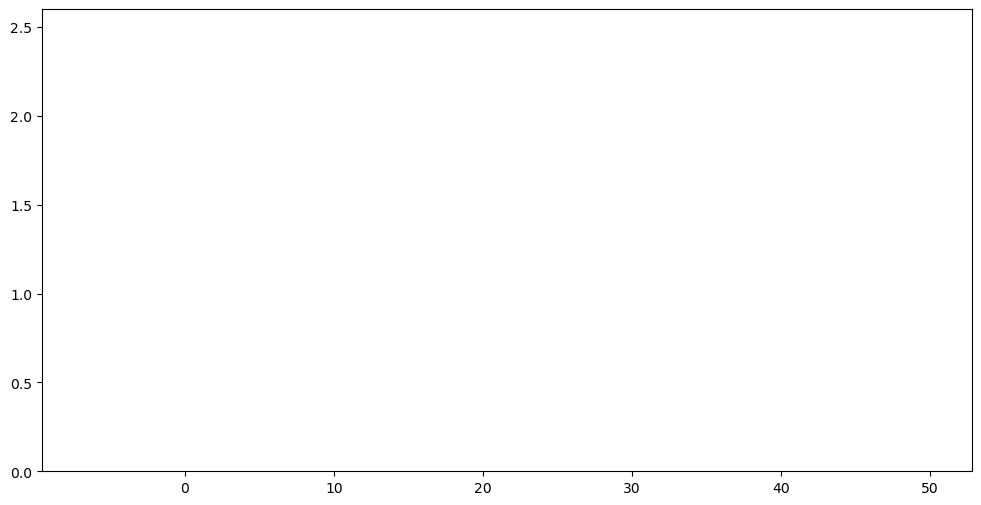

In [272]:
fig, ax = plt.subplots()  
total_wells = 48
ax.set_xlim(-total_wells*0.2, total_wells*1.1)
ax.set_ylim(0, 2.6)

new_slice = lcData.loc[lcData.index.isin([1,2,3,4,5,6,7,8,9,10])]
markers = ["o", "v", "^", "<", ">", "1", "s", "p", "P", "+"]

ax.scatter(new_slice["well"], new_slice["time"], s = new_slice["area"].apply(lambda x: math.ceil(x * 0.2)**2), marker = markers)